# A Synopsis Generator, but for Football Match
*Crafted by Farras Ezra (🇮🇩) as part of W1 practice of Ed Donner's AI Engineering course*



## Overview of the solution

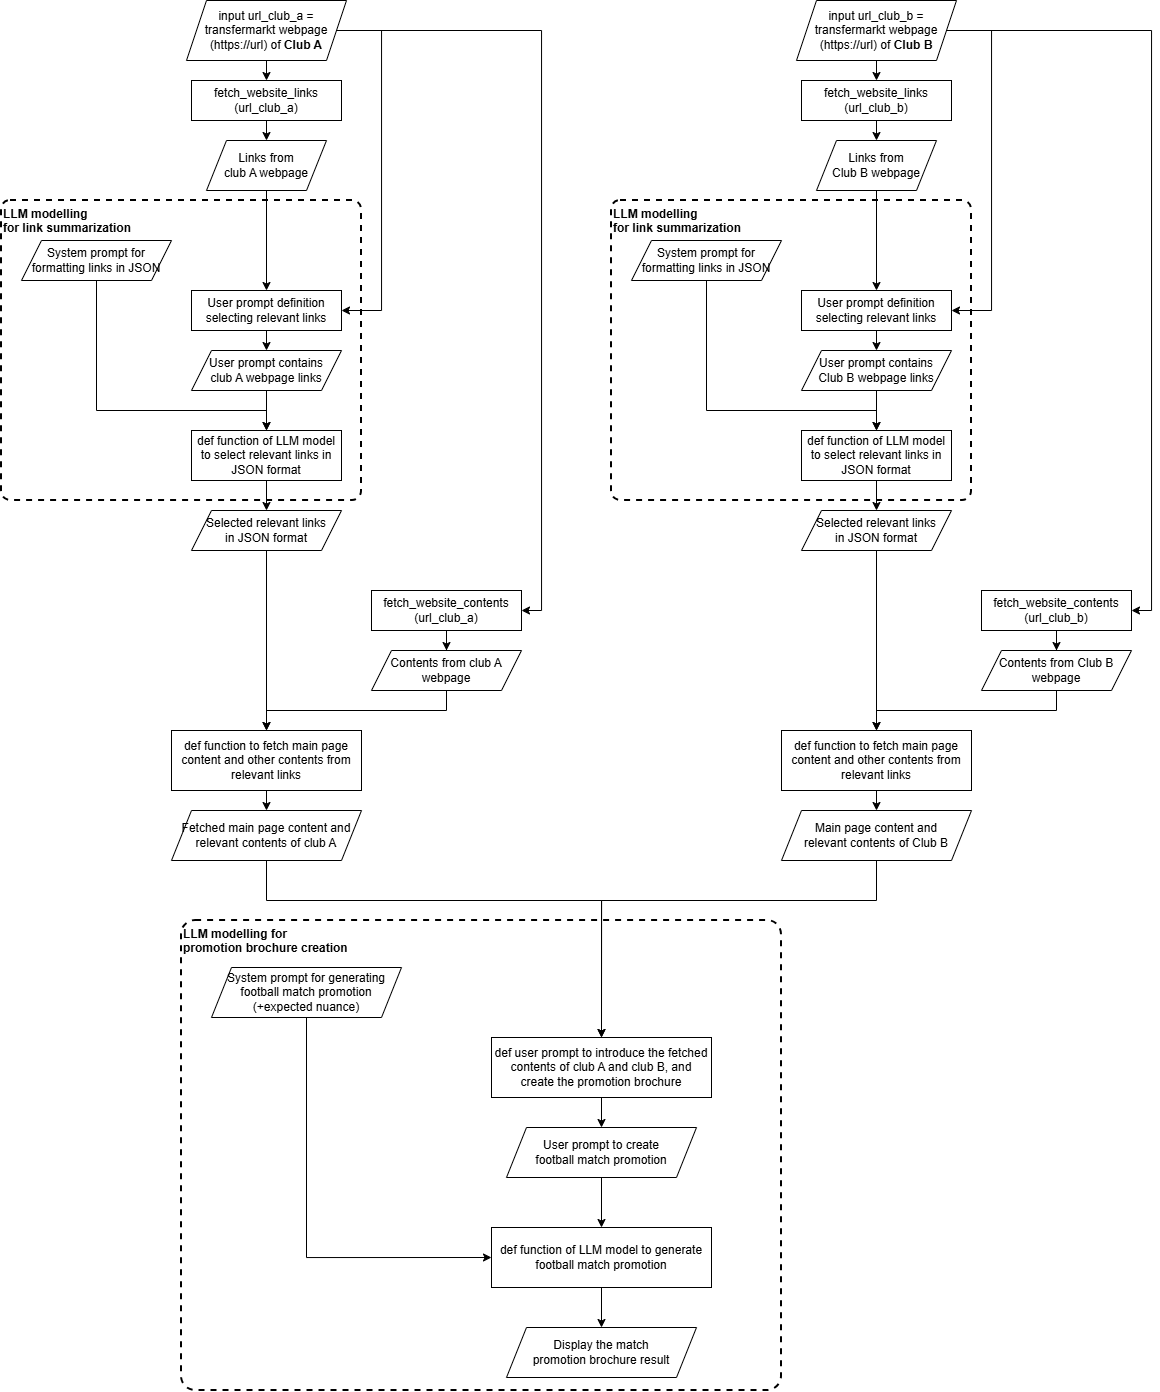

In [3]:
from IPython.display import display
from PIL import Image

path = "Football_Match_Narrative_LLM-Concept.png"
with Image.open(path) as i:
    display(i)


## Step 1: Initialization and function definitions

In [2]:
import os
import requests
import json
from bs4 import BeautifulSoup
from IPython.display import Markdown, display, update_display
from openai import OpenAI
from dotenv import load_dotenv

"""Website fetching functions"""
# Standard headers to fetch a website
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}


def fetch_website_contents(url):
    """
    Return the title and contents of the website at the given url;
    truncate to 2,000 characters as a sensible limit
    """
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    title = soup.title.string if soup.title else "No title found"
    if soup.body:
        for irrelevant in soup.body(["script", "style", "img", "input"]):
            irrelevant.decompose()
        text = soup.body.get_text(separator="\n", strip=True)
    else:
        text = ""
    return (title + "\n\n" + text)[:2_000]

def fetch_website_links(url):
    """
    Return the links on the webiste at the given url
    I realize this is inefficient as we're parsing twice! This is to keep the code in the lab simple.
    Feel free to use a class and optimize it!
    """
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    links = [link.get("href") for link in soup.find_all("a")]
    return [link for link in links if link]

"""LLM model initiation"""
LLM_model = "llama3.2"
base_url = "http://localhost:11434/v1"
api_key = 'ollama'
LLM_API = OpenAI(base_url = base_url, api_key = api_key)

## Step 2: Definition of LLM Model #1: Relevant Link Filtering/Selection
*System prompt, User prompt, and LLM model definition*

In [18]:
"""AI Modelling for Link Selector"""
linkfetch_systemprompt = """
    You are provided with a list of links found on transfermarkt.com webpage of a football club.
    You are knowledgable in world football, fluent in German language (since transfermarkt is using German) 
    and able to decide which of the links would be most relevant to include in a description of a football club,
    such as links to Trophy/Achievement history, player list & profile, or match fixtures page.
    RULES:
    - Copy URLs EXACTLY as they appear in the list. Do not modify, combine, or invent URLs.
    - For relative links (starting with /), prepend with https://www.transfermarkt.com
    - Always respond with this exact JSON structure:
        {"links": [{"type": "...", "url": "..."}]}
    - Include 1 URL per dictionary, do not include more than 1 URL in one dictionary. 
    If there are similar links, split into different dictionary
    - Never return a flat dict. Never return social media links.
    The "url" field must be a plain URL string only. 
    Ensure the URL is clean, never include HTML tags, markdown, space, or any other formatting
    """

def linkfetch_user_prompt(url):
    user_prompt = f""""
    You are looking at list of links on the website {url},
    Please decide which of these are relevant web links for describing a football club.
    respond with the full https URL in JSON format.
    Only include links relevant to: squad/kader, trophy history (erfolge), 
    player profiles (spieler), transfers, and performance stats (leistungsdaten).
    Exclude: betting, community, beliebtheit, social media, navigation links.

    Links (some might be relative links):
    """
    links = fetch_website_links(url)
    def prefilter_links(links: list[str]) -> list[str]:
        keywords = ['erfolge', 'kader', 'spieler', 'transfers', 'leistungsdaten', 
                'platzierungen', 'transferrekorde', 'profil']
        return [l for l in links if any(k in l for k in keywords)]
    user_prompt += "\n".join(prefilter_links(links))
    return user_prompt

def select_relevant_links(url):
    print(f"Selecting relevant links for {url} by calling {LLM_model}...")
    response = LLM_API.chat.completions.create(
        model = LLM_model,
        messages = [
            {"role": "system", "content": linkfetch_systemprompt},
            {"role": "user", "content": linkfetch_user_prompt(url)}
        ],
        response_format={"type": "json_object"}
    )
    result = response.choices[0].message.content
    links = json.loads(result)
    print(f"Found {len(links['links'])} relevant links")
    print(links['links'])
    return links

#"""Fetching starts"""
#Club A
#print(f"Fetching Home club webpage... Your user prompt is: \n{linkfetch_user_prompt(url_club_a)}")
#relevant_links_club_a = select_relevant_links(url_club_a)
#print(f"Fetching Away club webpage... Your user prompt is: \n{linkfetch_user_prompt(url_club_b)}")
#relevant_links_club_b = select_relevant_links(url_club_b)

## Step 3: Fetching the page and relevant links 
*Defining page fetching function from relevant links, by wrapping LLM Model #1*

In [13]:
def fetch_page_and_relevant_links (url):
    contents = fetch_website_contents(url)
    relevant_links = select_relevant_links(url)
    result = f"## Landing page:\n\n{contents}\n## Relevant Links:\n"
    for link in relevant_links['links']:
        result += f"\n\n## Link: {link['type']}\n"
        result += fetch_website_contents(link['url'])
    return result

#print(fetch_page_and_relevant_links(url_club_a))
#print(fetch_page_and_relevant_links(url_club_b))


## Step 4: Defining LLM Model #2: Pre-Match Synopsis Generator
*System prompt, user prompt, and LLM model definition*

In [20]:
synopsis_system_prompt = """
You are a football analyst that analyzes the contents of several club webpages from transfermarkt.com website
and creates a masterpiece, energetic, intriguing, thrilling synopsis about a match between two clubs. 
They will play in UEFA Champions League Final, highest tier of football tournament in the world.
Respond in markdown without code blocks.
Include details of clubs, potential clashouts, and narrative if you have the information.
"""

def synopsis_user_prompt(club_a_name, url_a, club_b_name, url_b):
    user_prompt = f""""
    You are looking at a club called: {club_a_name} that will play at Home, and the other club called: {club_b_name} that will visit as Away
    Use following information to build a short synopsis of a football match between Home and Away in markdown without code blocks.
    Here are the contents of Home Club's landing page and other relevant pages;\n
    """
    user_prompt += fetch_page_and_relevant_links(url_a)
    user_prompt = user_prompt[:2_500] #Truncate if more than 2,500 chars
    
    user_prompt += """and here are the contents of Away club's landing page and other relevant pages;\n
    """
    user_prompt += fetch_page_and_relevant_links(url_b)
    user_prompt = user_prompt[:5_000] #Truncate if more than 5,000 chars
    return user_prompt

def create_synopsis_stream(club_a_name, url_a, club_b_name, url_b):
    stream = LLM_API.chat.completions.create(
        model = LLM_model,
        messages = [
            {"role": "system", "content": synopsis_system_prompt},
            {"role": "user", "content": synopsis_user_prompt(club_a_name, url_a, club_b_name, url_b)}
        ],
        stream = True
    )
    response = ""
    display_handle = display(Markdown(""), display_id = True)
    for chunk in stream:
        response += chunk.choices[0].delta.content or ''
        update_display(Markdown(response), display_id=display_handle.display_id)

## Final Step: Generating the Pre-Match Synopsis

In [22]:
#print("Paste the transfermarkt url for the Home club")
#club_name_a = input("Enter the Home club name")
#url_club_a = input("https://www.transfermarkt.com/<club code>/startseite/verein/<xx>")

#print("Paste the transfermarkt url for the Away club")
#club_name_b = input("Enter the Away club name")
#url_club_b = input("https://www.transfermarkt.com/<club code>/startseite/verein/<xx>")

"""For testing"""
club_name_a = "Paris-Saint Germain"
url_club_a = "https://www.transfermarkt.com/paris-saint-germain/startseite/verein/583"
club_name_b = "Arsenal FC"
url_club_b = "https://www.transfermarkt.com/fc-arsenal/startseite/verein/11"

print(f"You have provided the Home and Away club links:\nHome club ({club_name_a}): {url_club_a}\nAway club ({club_name_b}): {url_club_b}.")

"""Link Fetching"""
print(fetch_website_links(url_club_a))
print(fetch_website_links(url_club_b))

#user_prompt = synopsis_user_prompt(club_name_a, url_club_a, club_name_b, url_club_b)
#print(user_prompt)
create_synopsis_stream(club_name_a, url_club_a, club_name_b, url_club_b)

You have provided the Home and Away club links:
Home club (Paris-Saint Germain): https://www.transfermarkt.com/paris-saint-germain/startseite/verein/583
Away club (Arsenal FC): https://www.transfermarkt.com/fc-arsenal/startseite/verein/11.
['/', '/detailsuche/spielerdetail/suche', '/', '/navigation/transfersundgeruechte', '/navigation/marktwerte', '/navigation/wettbewerbe', '/navigation/statistiken', '/navigation/community', '/navigation/gaming', '/uefa-champions-league/startseite/wettbewerb/CL', '/premier-league/startseite/wettbewerb/GB1', '/laliga/startseite/wettbewerb/ES1', '/serie-a/startseite/wettbewerb/IT1', '/bundesliga/startseite/wettbewerb/L1', '/champions-league/startseite/pokalwettbewerb/CL', '/agent-support/beraterIndex/berater', '/berater/beraterfirmenuebersicht/berater', '/premium-service/berater', '/statistik/neuestetransfers', '/rumour-mill/detail/forum/154', '/aktuell/newsarchiv', '/whatsMyValue', '/spieler-statistik/wertvollstespieler/marktwertetop', '/spieler-statist

**The Grand Finale: Paris Saint-Germain vs Arsenal FC**
======================================================

The stage is set for the ultimate showdown in the UEFA Champions League Final, as two powerhouses of European football clash in front of a packed Parc des Princes. The hosts, Paris Saint-Germain, are looking to lift their first-ever Champions League trophy, while the visitors, Arsenal FC, aim to add another prestigious title to their burgeoning legacy.

**The Strengths and Weaknesses**
-------------------------------

Paris Saint-Germain boast an attacking arsenal of top-class talent, with stars like Lionel Messi, Kylian Mbappé, and Neymar Jr. leading the charge. Their midfield is also incredibly potent, featuring the likes of Vitinha and Warren Zaïre-Emery. However, PSG's backline has shown vulnerability at times, particularly in the high-intensity counter-attacks that Arsenal employ.

Arsenal FC, on the other hand, have transformed under the guidance of Mikel Arteta. Their midfield is a joy to behold, with Thomas Partey and Bukayo Saka providing creativity and pace. The Gunners' defense has also looked solid, with William Saliba patrolling the backline alongside Ben White.

**The Key matchups**
------------------

This match promises to be an intense contest, with several key battles expected to determine the outcome:

*   **Goalkeeper Showdown**: As both Goalkeepers are excellent at what they do. PSG's Matvey Safonov against  Kepa Arrizabalaga from Arsenal FC.
*   **Midfield Duel**: The midfield is where the match is likely won and lost. Vitinha against Thomas Partey, Willian Pacho versus Bukayo Saka for PSG and Arsenal respectively will be key battle
*   **Frontline Clash**: This should be the highlight of the match. Lionel Messi facing off against Gabriel.

**The Prediction**
-----------------

Based on the performances of both teams throughout the competition, I predict a thrilling encounter with multiple goals. The sheer quality of talent on display ensures that this will be an instant classic.

Paris Saint-Germain's attacking threat and midfield prowess should ultimately prove too much for Arsenal FC's rearguard. Expect PSG to come out on top in a high-scoring affair. **5-3 to PS**

But remember: in football, nothing is ever guaranteed. The beauty of the beautiful game lies in its unpredictability!